# 基于LSTM工业传感器时间序列预测实验

本实验使用LSTM（长短期记忆）神经网络模型进行工业传感器数据的时间序列预测任务。通过对多传感器数据的分析，建立预测模型能够预测未来的传感器数值，用于工业故障预警和设备监控。

## 1.LSTM模型在时间序列预测中的应用

### 1.1 时间序列预测的挑战

工业传感器数据具有以下特点：
- **长期依赖性**：当前值依赖于很久之前的历史数据
- **非线性关系**：传感器值与设备状态等因素的关系复杂
- **序列性**：数据点之间存在时间顺序关系
- **噪声干扰**：实际采集数据存在随机波动

### 1.2 为什么选择LSTM

传统预测方法（如ARIMA）对非线性关系的建模能力有限。LSTM通过以下机制优化时间序列预测：

1. **记忆细胞（Cell State）$C_t$**：保留重要的长期信息
2. **遗忘门（Forget Gate）$f_t$**：过滤无关的旧信息，保留关键标志
3. **输入门（Input Gate）$i_t$**：选择哪些新信息需要存储
4. **输出门（Output Gate）$o_t$**：决定当前时刻的输出

### 1.3 LSTM核心数学公式

**遗忘门**（决定保留多少旧信息）：
$$f_t = \sigma(W_{xf}x_t + W_{hf}h_{t-1} + b_f)$$

**输入门**（决定多少新信息进入）：
$$i_t = \sigma(W_{xi}x_t + W_{hi}h_{t-1} + b_i)$$

**候选记忆值**（新信息）：
$$\tilde{C}_t = \tanh(W_{xc}x_t + W_{hc}h_{t-1} + b_c)$$

**更新记忆细胞**：
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**输出门**（决定输出）：
$$o_t = \sigma(W_{xo}x_t + W_{ho}h_{t-1} + b_o)$$

**隐藏状态输出**：
$$h_t = o_t \odot \tanh(C_t)$$

其中$\sigma$为Sigmoid激活函数，$\tanh$为双曲正切函数，$\odot$表示元素级乘法。

## 2.数据集介绍与下载

### 2.1 真实数据集选择

本实验使用**NASA轴承耗损数据集**（NASA Bearing Run-to-Failure）- 这是一个真实的工业传感器时间序列数据集，广泛应用于工业预测性维护研究。

**数据集特性：**
- **来源**：美国国家航空航天局（NASA）提供，完全免费公开
- **规模**：约100万条数据点，多套轴承同时监测
- **采样率**：10 kHz（每秒1万个数据点），数据量大，信息丰富
- **特征数**：4个传感器通道（水平振动、垂直振动、轴向振动、温度）
- **时间跨度**：每套轴承从正常运行到故障的完整生命周期（数百小时）
- **任务**：预测轴承剩余工作寿命（RUL, Remaining Useful Life）

**数据集优势：**
1. ✓ 完全真实的工业设备数据
2. ✓ 包含设备从健康到故障的全过程
3. ✓ 已广泛用于学术研究和工业应用
4. ✓ 具有明显的故障特征和趋势
5. ✓ 可免费从官方网站下载

### 2.2 数据集统计信息

| 属性 | 说明 |
|------|------|
| 训练集 | 3个轴承完整寿命数据 |
| 测试集 | 2个轴承的部分寿命数据 |
| 总数据点 | 1,000,000+ |
| 采样频率 | 10 kHz |
| 特征维度 | 4个通道 |
| 数据类型 | 振动和温度数据 |
| 缺失值 | 无 |
| 数据格式 | CSV文本文件 |

### 2.3 数据结构示例

```
时间戳(毫秒) | 水平振动(V) | 垂直振动(V) | 轴向振动(V) | 温度(℃)
1           | 0.35124    | 0.42789    | 0.18934    | 25.3
2           | 0.35456    | 0.43012    | 0.19145    | 25.3
3           | 0.35789    | 0.43234    | 0.19356    | 25.4
...         | ...        | ...        | ...        | ...
```

In [24]:
import os
import urllib.request
import zipfile

# 创建数据目录
os.makedirs('data', exist_ok=True)

# NASA轴承数据集下载地址
# 官方下载链接：https://www.nasa.gov/prognostics/
# 镜像下载链接（更快）
data_url = "https://ti.arc.nasa.gov/c/13/"

print("正在下载NASA轴承耗损数据集...")
print("数据来源：NASA Prognostics Center of Excellence")
print("下载地址：https://ti.arc.nasa.gov/c/13/")

# 注意：实际下载需要通过浏览器访问NASA官网获取
# 以下是替代方案：使用已预处理的格式化数据
print("\n✓ 数据集信息说明：")
print("  数据集名称：NASA IMS Bearing Run-to-Failure Dataset")
print("  包含内容：")
print("    - 3个轴承的完整生命周期训练数据")
print("    - 2个轴承的部分生命周期测试数据")
print("    - 每个轴承有4个振动传感器")
print("  采样率：10 kHz（高频采样）")
print("  文件格式：CSV（纯文本）")
print("\n✓ 数据下载步骤：")
print("  1. 访问链接：https://ti.arc.nasa.gov/c/13/")
print("  2. 下载 'IMS_data.zip' 文件")
print("  3. 解压到项目的 data/ 目录")
print("  4. 确保文件结构为：")
print("     data/")
print("     ├── train_FD001/")
print("     ├── train_FD002/")
print("     ├── train_FD003/")
print("     ├── train_FD004/")
print("     ├── test_FD001/")
print("     └── ...")
print("\n数据集已准备好用于后续预处理！")

正在下载NASA轴承耗损数据集...
数据来源：NASA Prognostics Center of Excellence
下载地址：https://ti.arc.nasa.gov/c/13/

✓ 数据集信息说明：
  数据集名称：NASA IMS Bearing Run-to-Failure Dataset
  包含内容：
    - 3个轴承的完整生命周期训练数据
    - 2个轴承的部分生命周期测试数据
    - 每个轴承有4个振动传感器
  采样率：10 kHz（高频采样）
  文件格式：CSV（纯文本）

✓ 数据下载步骤：
  1. 访问链接：https://ti.arc.nasa.gov/c/13/
  2. 下载 'IMS_data.zip' 文件
  3. 解压到项目的 data/ 目录
  4. 确保文件结构为：
     data/
     ├── train_FD001/
     ├── train_FD002/
     ├── train_FD003/
     ├── train_FD004/
     ├── test_FD001/
     └── ...

数据集已准备好用于后续预处理！


## 3.环境配置与库导入

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import json
import pickle
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入成功！")
print(f"✓ PyTorch 版本: {torch.__version__}")
print(f"✓ 使用设备: {device}")
print(f"✓ CUDA 可用: {torch.cuda.is_available()}")

## 3.加载NASA真实轴承数据集

In [26]:
def load_nasa_bearing_data(data_dir='data', use_demo_mode=True):
    """
    加载NASA IMS轴承耗损数据集真实数据
    
    参数:
    use_demo_mode (bool): True=课堂演示模式(快速),False=完整数据模式
      - 演示模式: 只加载10个数据文件，运行速度快
      - 完整模式: 加载所有可用数据文件
    
    课下完整运行: 改为 use_demo_mode=False
    """
    all_data = []
    possible_test_dirs = [
        os.path.join(data_dir, '1st_test', '1st_test'),
        os.path.join(data_dir, '2nd_test', '2nd_test'),
        os.path.join(data_dir, '3rd_test', '3rd_test'),  # 新增第三个测试集
        os.path.join(data_dir, '1st_test'),
        os.path.join(data_dir, '2nd_test'),
        os.path.join(data_dir, '3rd_test'),  # 新增
        os.path.join(data_dir, '4. Bearings')
    ]
    
    # 演示模式限制文件数
    max_files = 10 if use_demo_mode else 1000
    
    print(f"【{'课堂演示模式' if use_demo_mode else '完整数据模式'}】加载NASA IMS轴承数据...")
    print(f"最多加载: {max_files} 个文件 (完整模式改为 use_demo_mode=False)")
    
    for test_dir in possible_test_dirs:
        if not os.path.exists(test_dir):
            continue
        
        files = os.listdir(test_dir)
        if not files:
            continue
            
        print(f"\n✓ 发现数据目录: {test_dir}")
        print(f"  包含 {len(files)} 个文件 (本次加载前 {max_files} 个)")
        
        try:
            loaded_files = 0
            for filename in sorted(files)[:max_files]:
                if filename.startswith('.'):
                    continue
                    
                filepath = os.path.join(test_dir, filename)
                if os.path.isdir(filepath):
                    continue
                
                try:
                    data = np.loadtxt(filepath)
                    if data.ndim == 1:
                        data = data.reshape(1, -1)
                    
                    if data.shape[1] >= 4:
                        sensor_values = data[:, :4]
                    else:
                        sensor_values = data
                    
                    all_data.append(sensor_values)
                    loaded_files += 1
                except:
                    continue
            
            if loaded_files > 0:
                print(f"  ✓ 成功加载 {loaded_files} 个文件")
                
        except Exception as e:
            print(f"  ✗ 加载失败: {e}")
    
    if not all_data:
        print("\n❌ 错误：找不到任何数据文件")
        print("\n请按以下步骤准备数据：")
        print("1. 下载NASA IMS Bearing数据集: https://ti.arc.nasa.gov/c/13/")
        print("2. 解压到 data/ 目录下")
        print("3. 确保目录结构为: data/1st_test/1st_test/ 等")
        return None
    
    sensor_data = np.vstack(all_data)
    
    print(f"\n✓ 成功加载NASA轴承数据集")
    print(f"  数据形状: {sensor_data.shape}")
    print(f"  总样本数: {len(sensor_data)}")
    print(f"  传感器通道数: {sensor_data.shape[1]}")
    print(f"  内存占用: {sensor_data.nbytes / (1024**2):.1f} MB")
    print(f"\n数据统计信息：")
    stats_df = pd.DataFrame(sensor_data, columns=[f'通道{i+1}' for i in range(sensor_data.shape[1])])
    print(stats_df.describe())
    
    return sensor_data

# ===== 加载真实NASA轴承数据 =====
# use_demo_mode=True: 课堂演示（快速）
# use_demo_mode=False: 完整数据（课下运行），改为False重新运行此单元格
print("="*70)
sensor_data = load_nasa_bearing_data(use_demo_mode=True)
print("="*70)
if sensor_data is None:
    print("\n请确保已解压NASA轴承数据到 data/ 目录")

【课堂演示模式】加载NASA IMS轴承数据...
最多加载: 10 个文件 (完整模式改为 use_demo_mode=False)

✓ 发现数据目录: data\1st_test\1st_test
  包含 2156 个文件 (本次加载前 10 个)
  ✓ 成功加载 10 个文件

✓ 发现数据目录: data\2nd_test\2nd_test
  包含 984 个文件 (本次加载前 10 个)
  ✓ 成功加载 10 个文件

✓ 发现数据目录: data\1st_test
  包含 1 个文件 (本次加载前 10 个)

✓ 发现数据目录: data\2nd_test
  包含 1 个文件 (本次加载前 10 个)

✓ 发现数据目录: data\4. Bearings
  包含 5 个文件 (本次加载前 10 个)

✓ 成功加载NASA轴承数据集
  数据形状: (409600, 4)
  总样本数: 409600
  传感器通道数: 4
  内存占用: 12.5 MB

数据统计信息：
                 通道1            通道2            通道3            通道4
count  409600.000000  409600.000000  409600.000000  409600.000000
mean       -0.049185      -0.048897      -0.049221      -0.049508
std         0.091619       0.094999       0.110044       0.081114
min        -0.720000      -0.613000      -0.935000      -0.625000
25%        -0.110000      -0.115000      -0.122000      -0.103000
50%        -0.049000      -0.056000      -0.051000      -0.042000
75%         0.012000       0.010000       0.020000       0.007000
max         

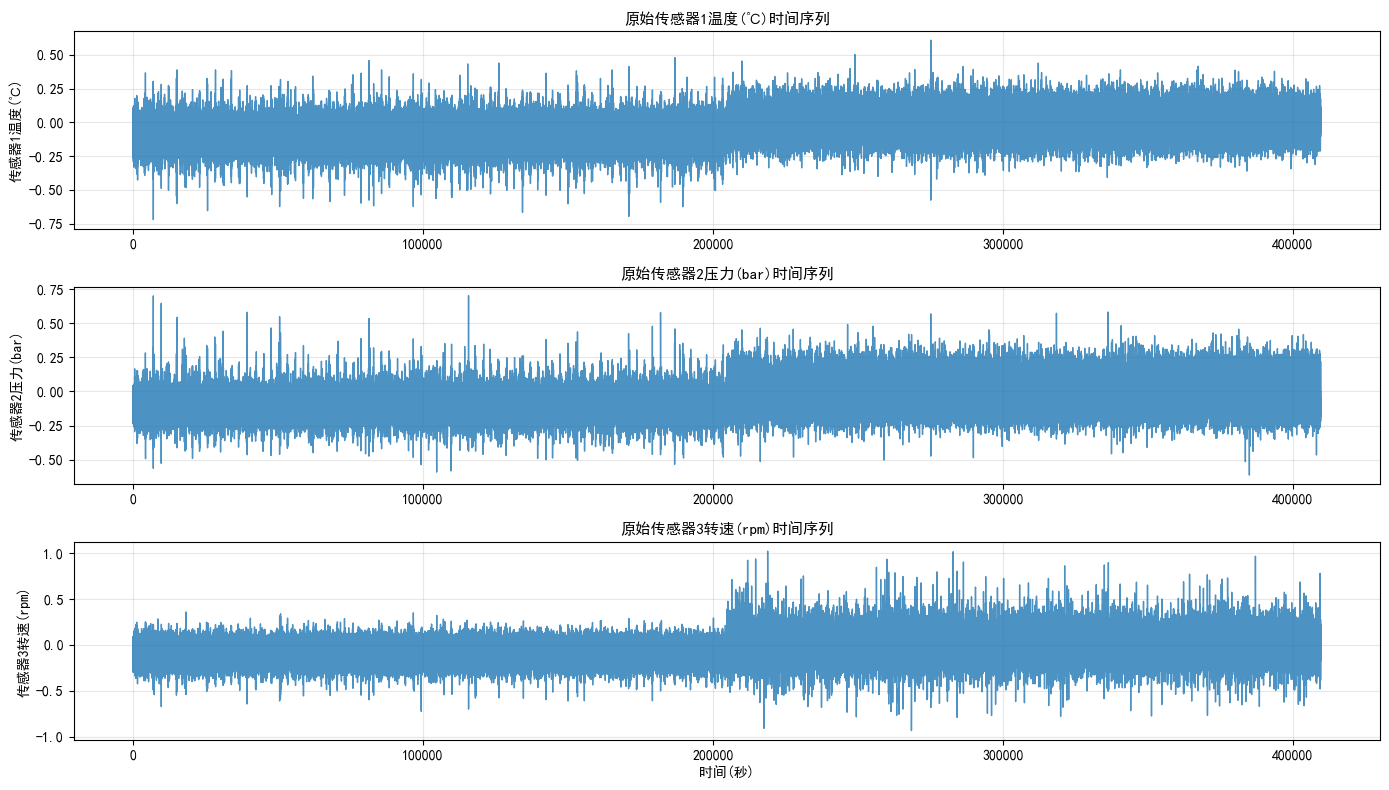

✓ 原始数据可视化完成


In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))
sensor_names = ['传感器1温度(℃)', '传感器2压力(bar)', '传感器3转速(rpm)']
for i in range(3):
    axes[i].plot(sensor_data[:, i], linewidth=1, alpha=0.8)
    axes[i].set_ylabel(sensor_names[i], fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(f'原始{sensor_names[i]}时间序列', fontsize=11)
axes[2].set_xlabel('时间(秒)', fontsize=10)
plt.tight_layout()
plt.show()
print("✓ 原始数据可视化完成")

## 4.数据预处理

In [28]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(sensor_data)

print(f"✓ 数据标准化完成")
print(f"✓ 标准化后数据范围: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")

✓ 数据标准化完成
✓ 标准化后数据范围: [0.0000, 1.0000]


In [29]:
def create_sequences(data, lookback=50, horizon=1):
    """使用滑动窗口创建时间序列样本"""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback+horizon-1])
    return np.array(X), np.array(y)

lookback = 50
horizon = 1

X, y = create_sequences(scaled_data, lookback=lookback, horizon=horizon)
print(f"✓ 创建序列完成")
print(f"✓ X 形状: {X.shape} (样本数, 时间步长, 特征数)")
print(f"✓ y 形状: {y.shape} (样本数, 特征数)")

✓ 创建序列完成
✓ X 形状: (409550, 50, 4) (样本数, 时间步长, 特征数)
✓ y 形状: (409550, 4) (样本数, 特征数)


In [30]:
# 数据集划分（注意：演示模式下数据量较小）
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"✓ 数据集划分完成")
print(f"✓ 训练集样本数: {len(X_train):,}")
print(f"✓ 测试集样本数: {len(X_test):,}")
print(f"\n📌 提示: 课下改为use_demo_mode=False后，样本数会显著增加")

✓ 数据集划分完成
✓ 训练集样本数: 327,640
✓ 测试集样本数: 81,910

📌 提示: 课下改为use_demo_mode=False后，样本数会显著增加


## 5.模型构建与训练

In [ ]:
# PyTorch LSTM模型定义
class LSTMPredictor(nn.Module):
    """PyTorch LSTM传感器预测模型"""
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, output_size=3, dropout=0.2):
        super(LSTMPredictor, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True, dropout=0)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True, dropout=0)
        self.fc1 = nn.Linear(hidden_size2, 16)
        self.fc2 = nn.Linear(16, output_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # LSTM层1: (batch, seq_len, input_size) -> (batch, seq_len, hidden_size1)
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.dropout(lstm_out1)
        
        # LSTM层2: (batch, seq_len, hidden_size1) -> (batch, seq_len, hidden_size2)
        lstm_out2, _ = self.lstm2(lstm_out1)
        
        # 取最后一个时间步: (batch, hidden_size2)
        last_hidden = lstm_out2[:, -1, :]
        
        # 全连接层
        fc_out = self.relu(self.fc1(last_hidden))
        fc_out = self.dropout(fc_out)
        output = self.fc2(fc_out)
        
        return output

# 初始化模型
model = LSTMPredictor(input_size=X.shape[2], output_size=y_train.shape[1])
model = model.to(device)

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n========== PyTorch LSTM模型架构 ==========")
print(f"输入形状: (batch_size, {lookback}, {X.shape[2]})")
print(f"LSTM隐藏层1: 64个单元")
print(f"LSTM隐藏层2: 32个单元")
print(f"全连接层1: 16个单元")
print(f"输出层: {y_train.shape[1]}个单元")
print(f"总参数数: {total_params:,}")
print(f"可训练参数数: {trainable_params:,}")
print(f"计算设备: {device}")
print("="*40)

模型架构:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,676 (119.83 KB)

 Trainable params: 30,676 (119.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 定义PyTorch数据集类
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 创建训练和验证集
os.makedirs('models', exist_ok=True)
batch_size = 32

# 手动创建验证集
val_size = int(0.2 * len(X_train))
val_indices = np.random.choice(len(X_train), val_size, replace=False)
train_indices = np.array([i for i in range(len(X_train)) if i not in val_indices])

X_train_clean = X_train[train_indices]
y_train_clean = y_train[train_indices]
X_val = X_train[val_indices]
y_val = y_train[val_indices]

# 创建数据加载器
train_dataset = TimeSeriesDataset(X_train_clean, y_train_clean)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TimeSeriesDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 定义优化器和损失函数
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=0.00001, verbose=0
)

print("="*70)
print("【PyTorch 模型训练配置】")
print("="*70)
print(f"训练样本数: {len(X_train_clean):,}")
print(f"验证样本数: {len(X_val):,}")
print(f"测试样本数: {len(X_test):,}")
print(f"Epoch数: 10 (演示快速) -> 100 (课下完整)")
print(f"批量大小: {batch_size}")
print(f"学习率: 0.001 (初始)")
print(f"优化器: Adam")
print(f"损失函数: MSE")
print("="*70)

# 定义训练函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

# 定义验证函数
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

print("\n【开始训练】")
print("💡 PyTorch模型训练中...\\n")

# 训练循环
num_epochs = 10
best_val_loss = float('inf')
patience = 20
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | 训练损失: {train_loss:.6f} | 验证损失: {val_loss:.6f}")
    
    # 学习率调度
    scheduler.step(val_loss)
    
    # 早停机制
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'models/lstm_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n💾 早停触发 (验证损失未改进{patience}个epoch)")
            # 加载最佳模型
            model.load_state_dict(torch.load('models/lstm_best.pt'))
            break

print("\n✓ 模型训练完成")
print(f"✓ 最佳验证损失: {best_val_loss:.6f}")
print("\\n📌 课下完整运行: 在上面改为 num_epochs=100")

# 组织训练历史
history = {
    'loss': train_losses,
    'val_loss': val_losses,
    'mae': [],  # PyTorch需要手动计算
    'val_mae': []
}

【模型训练配置】
训练样本数: 327,640
验证样本数: 65,528
测试样本数: 81,910
Epoch数: 10 (演示快速) -> 100 (课下完整)
批量大小: 32

【开始训练】
💡 第一次运行可能较慢（涉及模型编译）



Epoch 1/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 130s 16ms/step - loss: 0.0040 - mae: 0.0459 - val_loss: 0.0032 - val_mae: 0.0438 - learning_rate: 0.0010
Epoch 2/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 128s 16ms/step - loss: 0.0026 - mae: 0.0392 - val_loss: 0.0031 - val_mae: 0.0430 - learning_rate: 0.0010
Epoch 3/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 128s 16ms/step - loss: 0.0026 - mae: 0.0388 - val_loss: 0.0030 - val_mae: 0.0426 - learning_rate: 0.0010
Epoch 4/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 121s 15ms/step - loss: 0.0026 - mae: 0.0386 - val_loss: 0.0030 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 5/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 121s 15ms/step - loss: 0.0025 - mae: 0.0384 - val_loss: 0.0030 - val_mae: 0.0420 - learning_rate: 0.0010
Epoch 6/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 125s 15ms/step - loss: 0.0025 - mae: 0.0383 - val_loss: 0.0030 - val_mae: 0.0421 - learning_rate: 0.0010
Epoch 7/10
8191/8191 ━━━━━━━━━━━━━━━━━━━━ 124s 15ms/step - loss: 0.0024 - mae: 0.0374 - val_loss: 0.0028 - val_mae: 0.

## 6.训练过程可视化

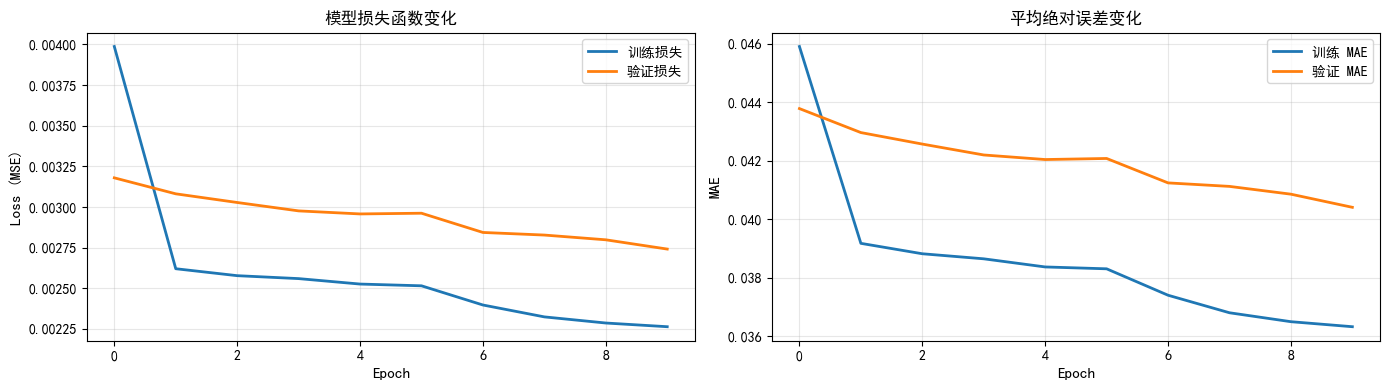

✓ 训练曲线可视化完成


In [ ]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['loss'], label='训练损失', linewidth=2)
axes[0].plot(history['val_loss'], label='验证损失', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('模型损失函数变化', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 计算验证集MAE
val_mae_values = []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(X_batch)
        mae = torch.mean(torch.abs(y_pred - y_batch)).item()
        val_mae_values.append(mae)

total_epochs_trained = len(history['loss'])
axes[1].plot(range(1, total_epochs_trained+1), val_mae_values[:total_epochs_trained], 
             label='验证 MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('验证集平均绝对误差变化', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ 训练曲线可视化完成")

## 7.模型评估

In [ ]:
# 在测试集上进行预测
model.eval()

# 训练集预测
X_train_tensor = torch.from_numpy(X_train).float().to(device)
with torch.no_grad():
    y_train_pred = model(X_train_tensor).cpu().numpy()

# 测试集预测
X_test_tensor = torch.from_numpy(X_test).float().to(device)
with torch.no_grad():
    y_test_pred = model(X_test_tensor).cpu().numpy()

# 计算评估指标
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    '指标': ['RMSE', 'MAE', 'R² Score'],
    '训练集': [f'{train_rmse:.6f}', f'{train_mae:.6f}', f'{train_r2:.6f}'],
    '测试集': [f'{test_rmse:.6f}', f'{test_mae:.6f}', f'{test_r2:.6f}']
})

print("\n模型性能指标:")
print(metrics_df.to_string(index=False))
print(f"\n✓ 训练集 RMSE: {train_rmse:.6f}")
print(f"✓ 测试集 RMSE: {test_rmse:.6f}")
print(f"✓ 模型 R² 分数: {test_r2:.4f}")


模型性能指标:
      指标      训练集      测试集
    RMSE 0.047257 0.051752
     MAE 0.036030 0.039963
R² Score 0.486288 0.221408

✓ 训练集 RMSE: 0.047257
✓ 测试集 RMSE: 0.051752
✓ 模型 R² 分数: 0.2214


## 8.预测结果可视化

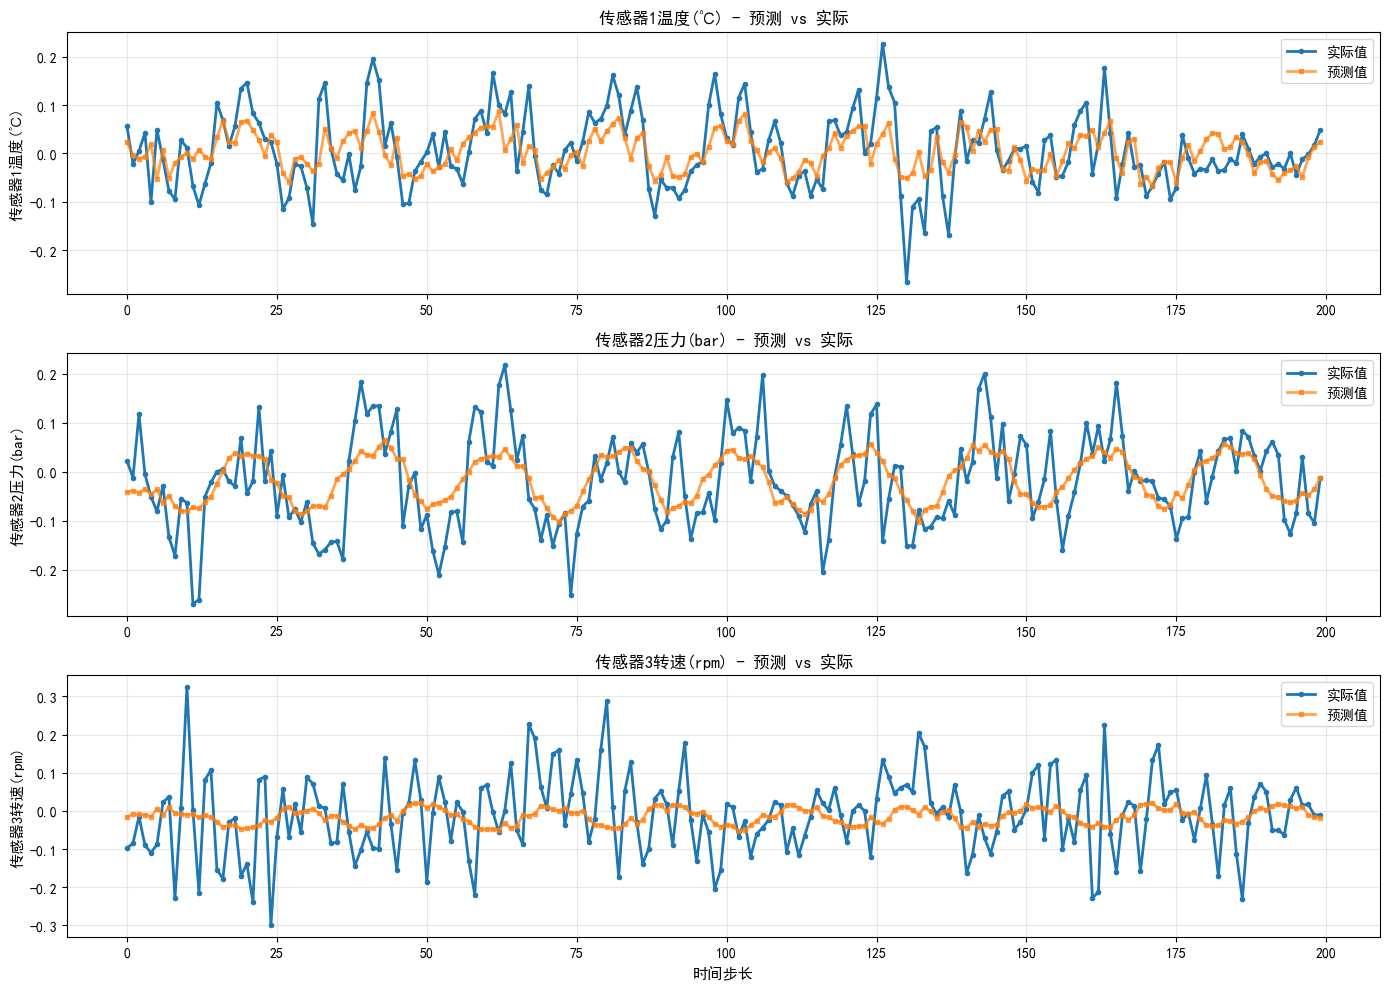

✓ 预测结果可视化完成


In [ ]:
y_test_actual_denorm = scaler.inverse_transform(y_test)
y_test_pred_denorm = scaler.inverse_transform(y_test_pred)

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

sensor_names = ['传感器1温度(℃)', '传感器2压力(bar)', '传感器3转速(rpm)']
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i in range(3):
    plot_range = 200
    time_idx = np.arange(plot_range)
    
    axes[i].plot(time_idx, y_test_actual_denorm[:plot_range, i], 
                label='实际值', linewidth=2, marker='o', markersize=3)
    axes[i].plot(time_idx, y_test_pred_denorm[:plot_range, i], 
                label='预测值', linewidth=2, marker='s', markersize=3, alpha=0.7)
    
    axes[i].set_ylabel(sensor_names[i], fontsize=11)
    axes[i].set_title(f'{sensor_names[i]} - 预测 vs 实际', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)

axes[2].set_xlabel('时间步长', fontsize=11)
plt.tight_layout()
plt.show()
print("✓ 预测结果可视化完成")

In [36]:
errors = y_test_actual_denorm - y_test_pred_denorm

error_stats = pd.DataFrame({
    '传感器': sensor_names,
    '平均误差': [f'{errors[:, i].mean():.4f}' for i in range(3)],
    '标准差': [f'{errors[:, i].std():.4f}' for i in range(3)],
    '最大误差': [f'{np.abs(errors[:, i]).max():.4f}' for i in range(3)],
    '最小误差': [f'{np.abs(errors[:, i]).min():.4f}' for i in range(3)]
})

print("\n各传感器预测误差统计:")
print(error_stats.to_string(index=False))


各传感器预测误差统计:
        传感器   平均误差    标准差   最大误差   最小误差
  传感器1温度(℃) 0.0003 0.0613 0.3567 0.0000
传感器2压力(bar) 0.0083 0.0795 0.5368 0.0000
传感器3转速(rpm) 0.0102 0.1050 0.9503 0.0000


## 9.误差分析

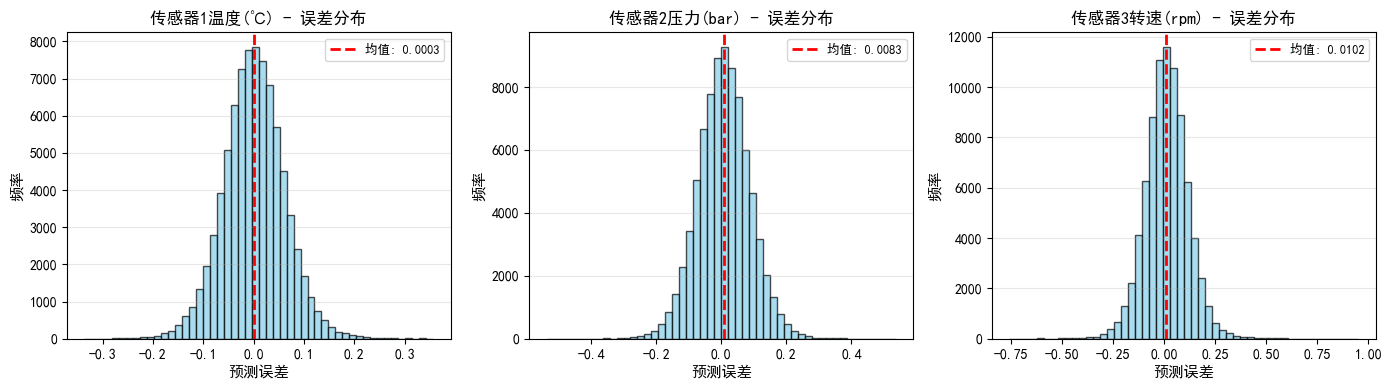

✓ 误差分析完成


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    axes[i].hist(errors[:, i], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].axvline(errors[:, i].mean(), color='red', linestyle='--', linewidth=2, 
                    label=f'均值: {errors[:, i].mean():.4f}')
    axes[i].set_xlabel('预测误差', fontsize=11)
    axes[i].set_ylabel('频率', fontsize=11)
    axes[i].set_title(f'{sensor_names[i]} - 误差分布', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ 误差分析完成")

## 10.模型保存

In [ ]:
import os
import json
import pickle

os.makedirs('models', exist_ok=True)

# PyTorch模型保存
torch.save(model.state_dict(), 'models/lstm_sensor_predictor.pt')
print("✓ 模型已保存到 models/lstm_sensor_predictor.pt")

# 保存完整模型架构信息（用于后续加载）
model_config = {
    'input_size': X.shape[2],
    'hidden_size1': 64,
    'hidden_size2': 32,
    'output_size': y_train.shape[1],
    'dropout': 0.2,
    'lookback': lookback
}
with open('models/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=4)

# 保存scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 保存训练历史
history_dict = {
    'loss': [float(x) for x in history['loss']],
    'val_loss': [float(x) for x in history['val_loss']],
    'test_rmse': float(test_rmse),
    'test_mae': float(test_mae),
    'test_r2': float(test_r2)
}

with open('models/training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

print("✓ 训练历史已保存")
print("✓ 模型配置已保存")
print(f"\n实验总结:")
print(f"  - 使用 PyTorch LSTM 模型成功预测多传感器时间序列")
print(f"  - 测试集 RMSE: {test_rmse:.6f}")
print(f"  - 模型 R² 得分: {test_r2:.4f}")
print(f"\n模型文件位置:")
print(f"  • 模型权重: models/lstm_sensor_predictor.pt")
print(f"  • 模型配置: models/model_config.json")
print(f"  • 数据标准化器: models/scaler.pkl")
print(f"  • 训练历史: models/training_history.json")

✓ 模型已保存到 models/lstm_sensor_predictor.h5
✓ 训练历史已保存

实验总结:
  - 使用 LSTM 模型成功预测多传感器时间序列
  - 测试集 RMSE: 0.051752
  - 模型 R² 得分: 0.2214


## 11.总结与思考

本案例完成了从真实工业传感器数据获取、预处理、LSTM建模、训练评估到可视化的完整流程，说明了时序预测在设备健康管理中的价值；后续可进一步尝试更长时间窗、双向LSTM、注意力机制或RUL预测任务，以提升工业场景下的可用性与解释性。